In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("academic_performance.csv")
df.head()


,StudentID,Gender,Age,StudyHours,Attendance,InternalMarks,FinalScore,Grade
0,S001,M,18,2.5,85.0,40,55.0,C
1,S002,F,19,3.0,90.0,45,60.0,B
2,S003,M,20,1.0,70.0,30,45.0,D
3,S004,F,21,4.5,95.0,48,78.0,A
4,S005,M,22,0.5,60.0,25,35.0,F


In [9]:
df.isnull().sum()


StudentID        0
Gender           0
Age              0
StudyHours       1
Attendance       1
InternalMarks    0
FinalScore       1
Grade            0
dtype: int64

In [11]:
df["StudyHours"] = df["StudyHours"].fillna(df["StudyHours"].mean())
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())
df["FinalScore"] = df["FinalScore"].fillna(df["FinalScore"].mean())


In [13]:
df[["StudyHours", "Attendance", "FinalScore"]].isna().sum()


StudyHours    0
Attendance    0
FinalScore    0
dtype: int64

In [15]:
df.describe()


,Age,StudyHours,Attendance,InternalMarks,FinalScore
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,20.000000,6.244898,81.612245,45.980000,69.877551
std,1.428571,5.568390,14.526283,16.886766,24.326548
min,18.000000,0.000000,40.000000,15.000000,20.000000
25%,19.000000,2.275000,75.250000,34.250000,52.250000
50%,20.000000,4.650000,85.500000,45.000000,73.500000
75%,21.000000,8.375000,91.750000,55.000000,87.500000
max,22.000000,25.000000,105.000000,85.000000,120.000000


In [17]:
df["Attendance"] = df["Attendance"].clip(0, 100)
df["FinalScore"] = df["FinalScore"].clip(0, 100)
df["InternalMarks"] = df["InternalMarks"].clip(0, 100)


In [20]:
df.describe()


,Age,StudyHours,Attendance,InternalMarks,FinalScore
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,20.000000,6.244898,81.512245,45.980000,68.977551
std,1.428571,5.568390,14.378453,16.886766,22.880678
min,18.000000,0.000000,40.000000,15.000000,20.000000
25%,19.000000,2.275000,75.250000,34.250000,52.250000
50%,20.000000,4.650000,85.500000,45.000000,73.500000
75%,21.000000,8.375000,91.750000,55.000000,87.500000
max,22.000000,25.000000,100.000000,85.000000,100.000000


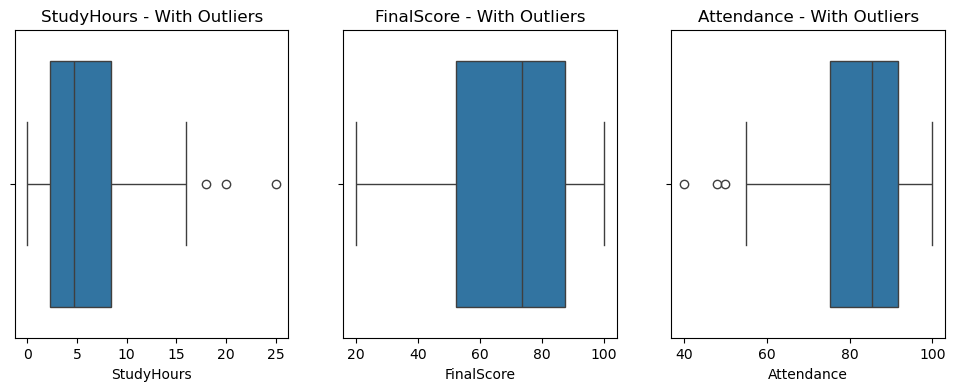

In [81]:
plt.figure(figsize=(12,4))


plt.subplot(1,3,1)
sns.boxplot(x=df["StudyHours"])
plt.title("StudyHours - With Outliers")


plt.subplot(1,3,2)
sns.boxplot(x=df["FinalScore"])
plt.title("FinalScore - With Outliers")


plt.subplot(1,3,3)
sns.boxplot(x=df["Attendance"])
plt.title("Attendance - With Outliers")

plt.show()


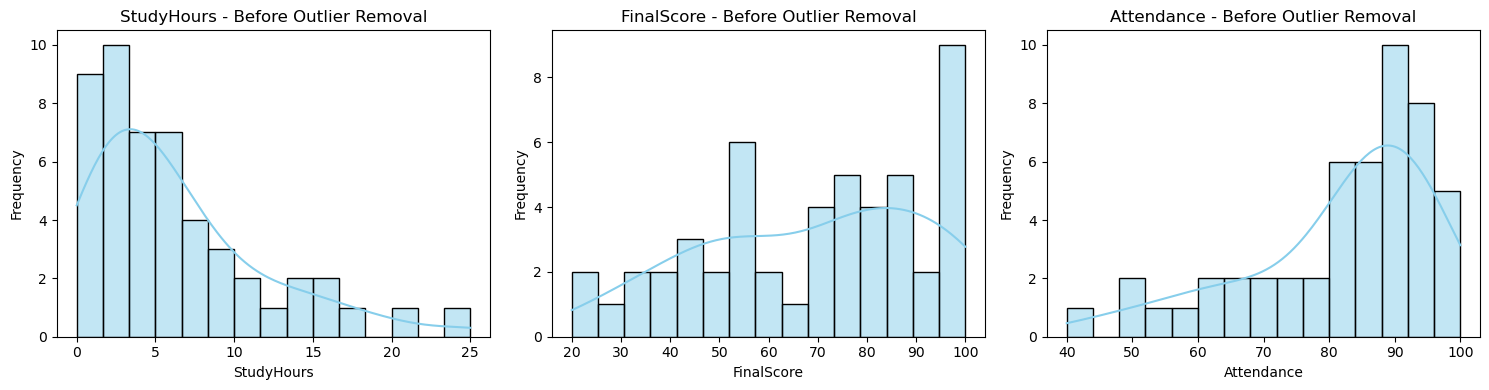

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["StudyHours", "FinalScore", "Attendance"]

plt.figure(figsize=(15,4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=15, kde=True, color="skyblue") 
    plt.title(f"{col} - Before Outlier Removal")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [85]:
df_iqr = df.copy()
numeric_cols = ["StudyHours", "FinalScore", "Attendance"]


outliers_exist = True

while outliers_exist:
    outliers_exist = False
    for col in numeric_cols:
        Q1 = df_iqr[col].quantile(0.25)
        Q3 = df_iqr[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

      
        outliers = df_iqr[(df_iqr[col] < lower) | (df_iqr[col] > upper)]
        if len(outliers) > 0:
            outliers_exist = True
         
            df_iqr = df_iqr[(df_iqr[col] >= lower) & (df_iqr[col] <= upper)]


for col in numeric_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    remaining = df_iqr[(df_iqr[col] < lower) | (df_iqr[col] > upper)]
    print(f"{col} outliers remaining: {len(remaining)}")



StudyHours outliers remaining: 0
FinalScore outliers remaining: 0
Attendance outliers remaining: 0


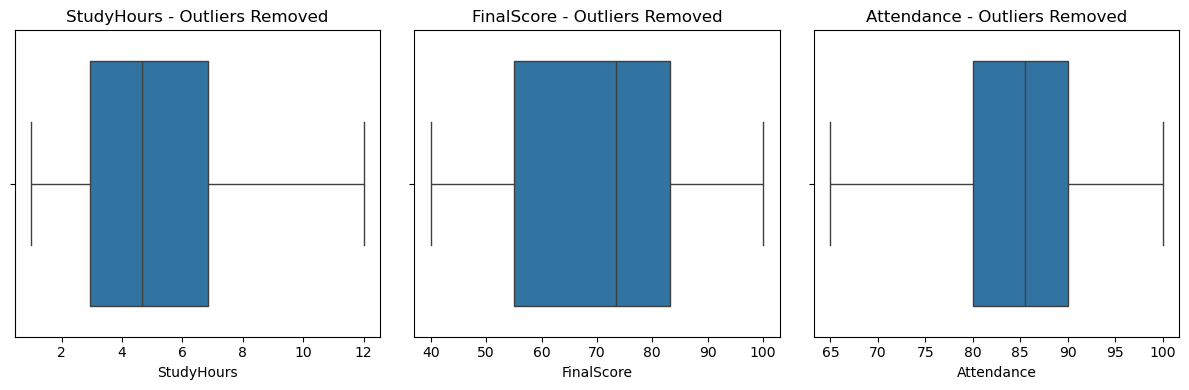

In [46]:

numeric_cols = ["StudyHours", "FinalScore", "Attendance"]

plt.figure(figsize=(12,4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df_iqr[col])
    plt.title(f"{col} - Outliers Removed")

plt.tight_layout()
plt.show()

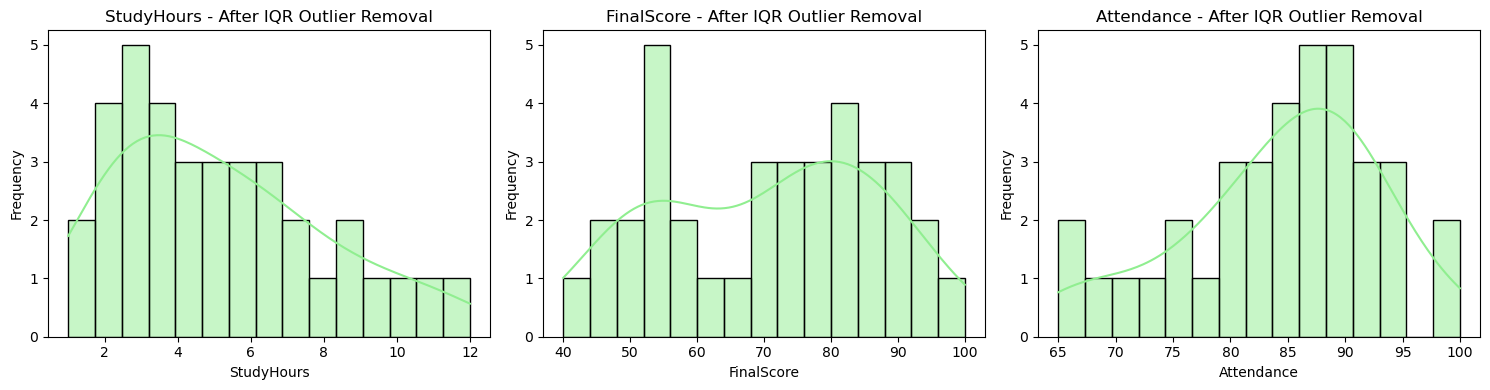

In [69]:
numeric_cols = ["StudyHours", "FinalScore", "Attendance"]

plt.figure(figsize=(15,4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_iqr[col], bins=15, kde=True, color="lightgreen")
    plt.title(f"{col} - After IQR Outlier Removal")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [48]:
d_z = df.copy() 


In [63]:
numeric_cols = ["StudyHours", "FinalScore", "Attendance"]
z_threshold = 3

for col in numeric_cols:
    z_col = np.abs(stats.zscore(d_z_cleaned[col]))
    remaining = np.sum(z_col > z_threshold)
    print(f"{col} outliers remaining (Z-score method): {remaining}")


StudyHours outliers remaining (Z-score method): 0
FinalScore outliers remaining (Z-score method): 0
Attendance outliers remaining (Z-score method): 0


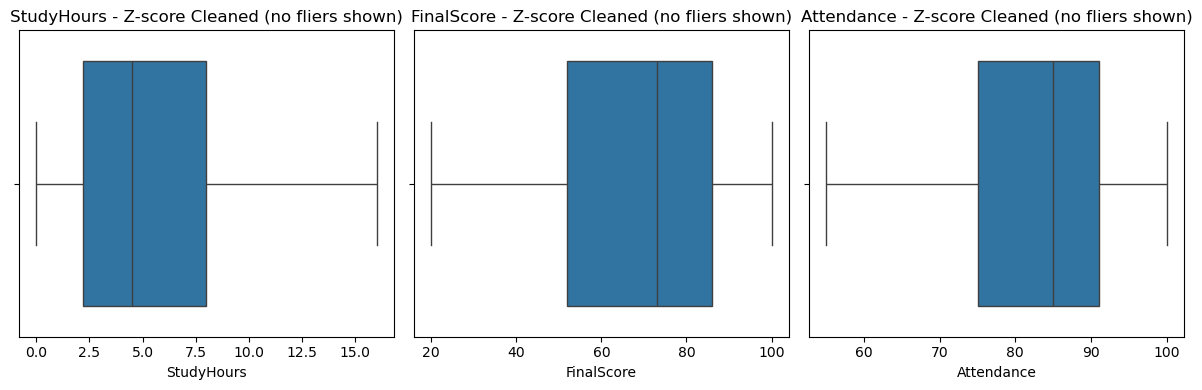

In [65]:
plt.figure(figsize=(12,4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=d_z_cleaned[col], showfliers=False)
    plt.title(f"{col} - Z-score Cleaned (no fliers shown)")

plt.tight_layout()
plt.show()


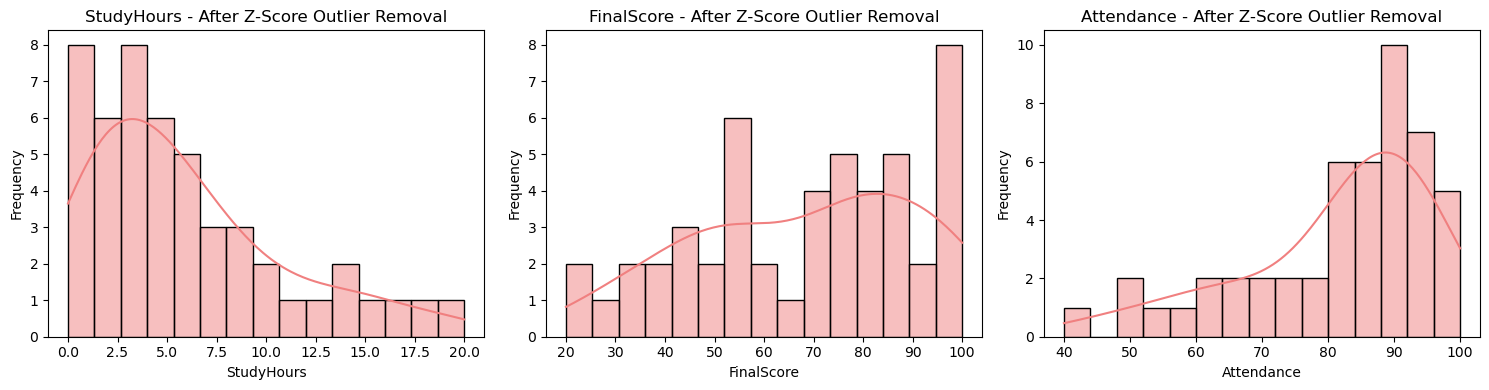

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["StudyHours", "FinalScore", "Attendance"]

plt.figure(figsize=(15,4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(d_z_cleaned[col], bins=15, kde=True, color="lightcoral")
    plt.title(f"{col} - After Z-Score Outlier Removal")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Frequency')

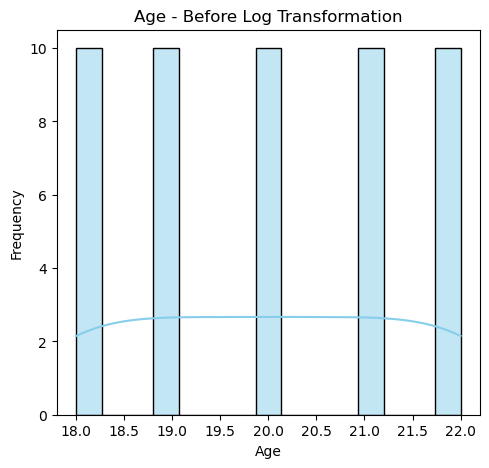

In [75]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Age"], bins=15, kde=True, color="skyblue")
plt.title("Age - Before Log Transformation")
plt.xlabel("Age")
plt.ylabel("Frequency")


In [77]:
df["Age_log"] = np.log1p(df["Age"])

Text(0.5, 0, 'Log(1 + Age)')

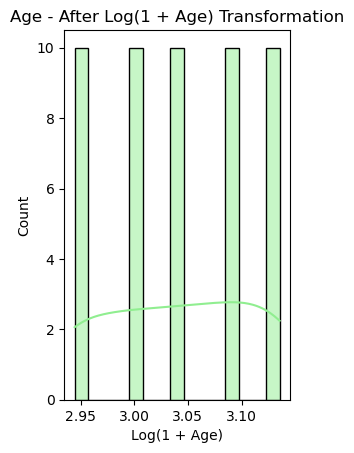

In [79]:
plt.subplot(1,2,2)
sns.histplot(df["Age_log"], bins=15, kde=True, color="lightgreen")
plt.title("Age - After Log(1 + Age) Transformation")
plt.xlabel("Log(1 + Age)")
